1. CÀI ĐẶT DÀNH CHO MÁY NÀO CHƯA CÓ (MỖI MÁY CHỈ CHẠY MỘT LẦN)

In [1]:
# Cài thư viện (chạy 1 lần duy nhất) (mỗi máy chạy 1 lần thôi nha)
!pip install xlrd
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2. IMPORT THƯ VIỆN

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    recall_score
)

3. TIỀN XỬ LÝ DỮ LIỆU (CHỈ 1 LẦN)

In [3]:
# Đọc dữ liệu
df = pd.read_excel('default of credit card clients.xls', header=1)

# Xóa ID vì nó chỉ là số thứ tự, không giúp gì cho việc dự báo
df.drop('ID', axis=1, inplace=True)

# Xử lý dữ liệu sai
# Cột Học vấn (EDUCATION) chỉ được phép từ 1 đến 4, nhưng lại có số 0, 5, 6. 
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

# Rename target, Đổi tên cột cuối cùng cho ngắn để dễ code
df.rename(columns={'default payment next month': 'target'}, inplace=True)

# Train/Test split
train_df, test_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['target']
)

# Scale dữ liệu
scaler = StandardScaler()

# Danh sách các cột chứa con số lớn cần chuẩn hóa
cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
        'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
        'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
        'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Tạo bản sao để không làm hỏng dữ liệu gốc
train_scaled = train_df.copy()
test_scaled = test_df.copy()

# Biến đổi các con số 
train_scaled[cols] = scaler.fit_transform(train_df[cols])
test_scaled[cols] = scaler.transform(test_df[cols])

4. HÀM ĐÁNH GIÁ CHUNG

In [4]:
def evaluate_model(model, X_test, y_test, model_name):
    print(f"============== ĐÁNH GIÁ MÔ HÌNH: {model_name.upper()} ==============")
    
    # 1. Dự đoán
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Xác suất cho class 1
    
    # 2. In Classification Report
    print(classification_report(y_test, y_pred))
    
    # --- Thiết lập không gian vẽ 2 biểu đồ ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 3. Vẽ Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
                xticklabels=["Không vỡ nợ", "Vỡ nợ"], 
                yticklabels=["Không vỡ nợ", "Vỡ nợ"])
    axes[0].set_title(f"Confusion Matrix - {model_name}")
    axes[0].set_xlabel("Dự đoán")
    axes[0].set_ylabel("Thực tế")
    
    # 4. Vẽ ROC Curve & Tính AUC (SỬA: Đây là phần được thêm mới)
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    
    axes[1].plot(fpr, tpr, color='blue', linewidth=2, label=f'AUC = {auc_score:.4f}')
    axes[1].plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
    axes[1].set_xlabel('False Positive Rate (FPR)')
    axes[1].set_ylabel('True Positive Rate (TPR)')
    axes[1].set_title(f'ROC Curve - {model_name}')
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print("\n")

5. CHUẨN BỊ DATA CHO CLASSIFICATION

In [5]:
X_train = train_scaled.drop(columns=['target'])
y_train = train_scaled['target']

X_test = test_scaled.drop(columns=['target'])
y_test = test_scaled['target']

6. LOGISTIC REGRESSION - BASELINE 

============== ĐÁNH GIÁ MÔ HÌNH: LOGISTIC REGRESSION ==============
              precision    recall  f1-score   support

           0       0.87      0.70      0.78      7009
           1       0.37      0.63      0.47      1991

    accuracy                           0.68      9000
   macro avg       0.62      0.66      0.62      9000
weighted avg       0.76      0.68      0.71      9000



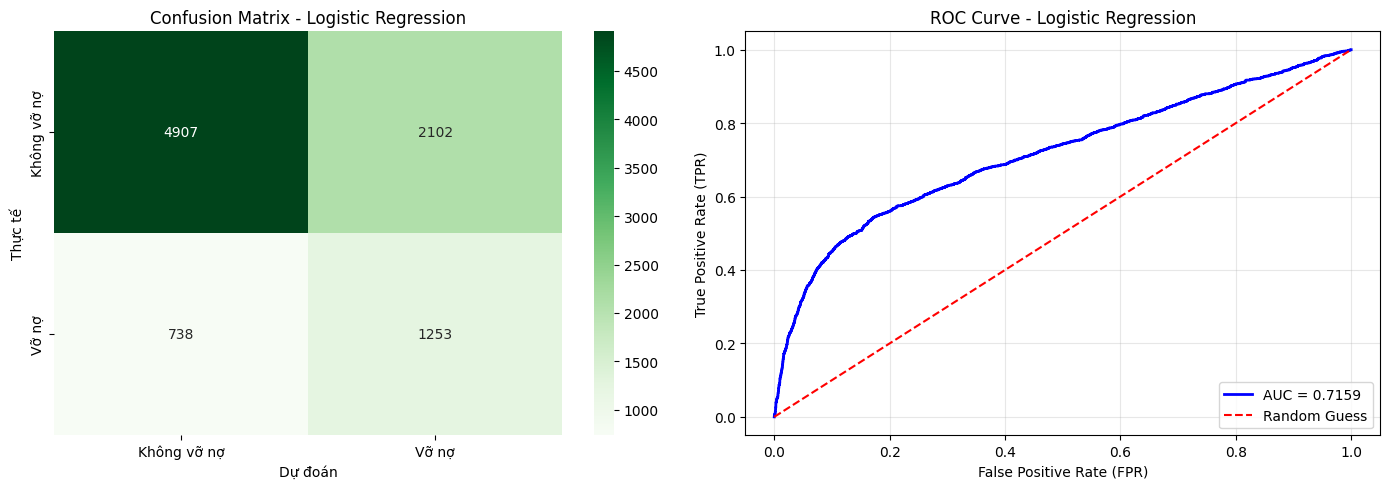

C:\Users\Tra My\AppData\Local\Temp\ipykernel_26664\56471823.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance, palette='viridis')


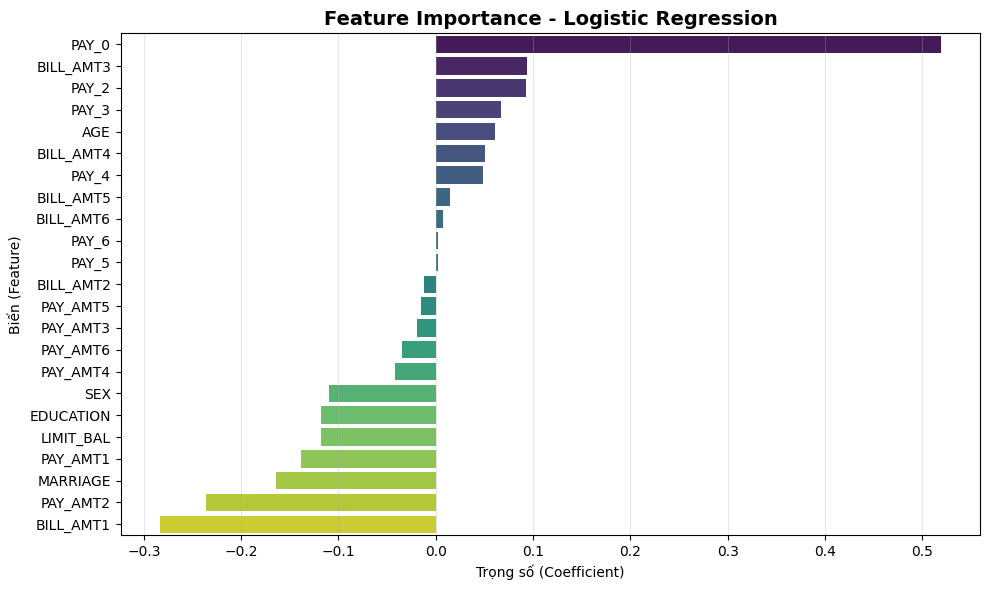

In [6]:
# 1. Khởi tạo và huấn luyện mô hình
logreg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
logreg.fit(X_train, y_train)

# 2. ĐÁNH GIÁ MÔ HÌNH
evaluate_model(logreg, X_test, y_test, "Logistic Regression")

# 3. VẼ FEATURE IMPORTANCE (Trọng số của các biến)
coef = logreg.coef_[0]

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coef
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=importance, palette='viridis')
plt.title('Feature Importance - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Trọng số (Coefficient)')
plt.ylabel('Biến (Feature)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

7. XGBOOST

C:\Users\Tra My\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [00:17:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


============== ĐÁNH GIÁ MÔ HÌNH: XGBOOST ==============
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      7009
           1       0.48      0.62      0.54      1991

    accuracy                           0.76      9000
   macro avg       0.68      0.71      0.69      9000
weighted avg       0.79      0.76      0.77      9000



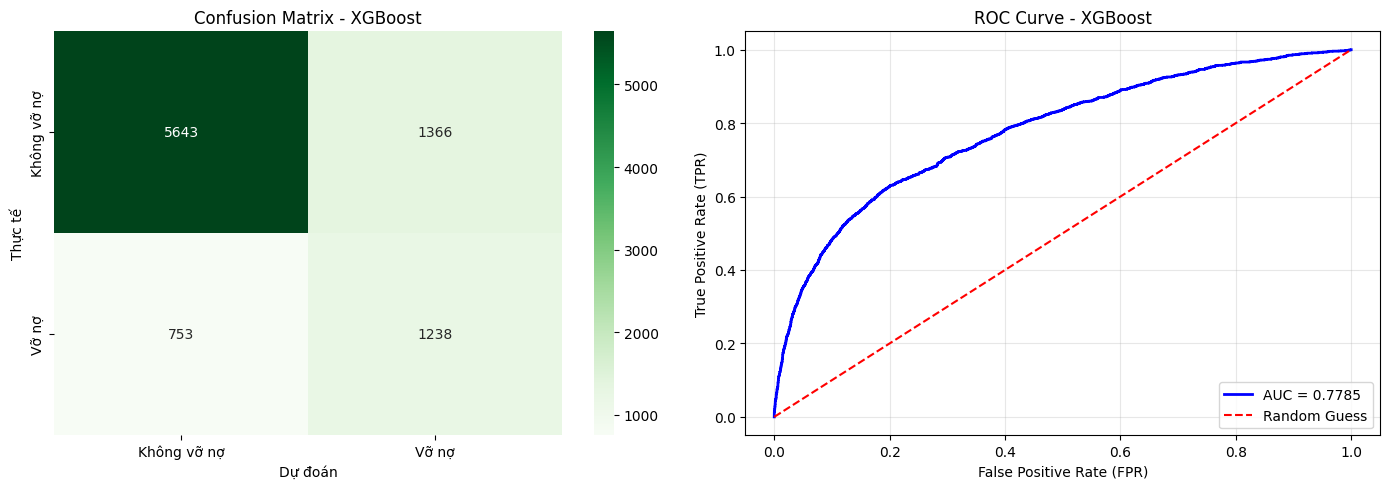

C:\Users\Tra My\AppData\Local\Temp\ipykernel_26664\4185780589.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_xgb, palette='magma')


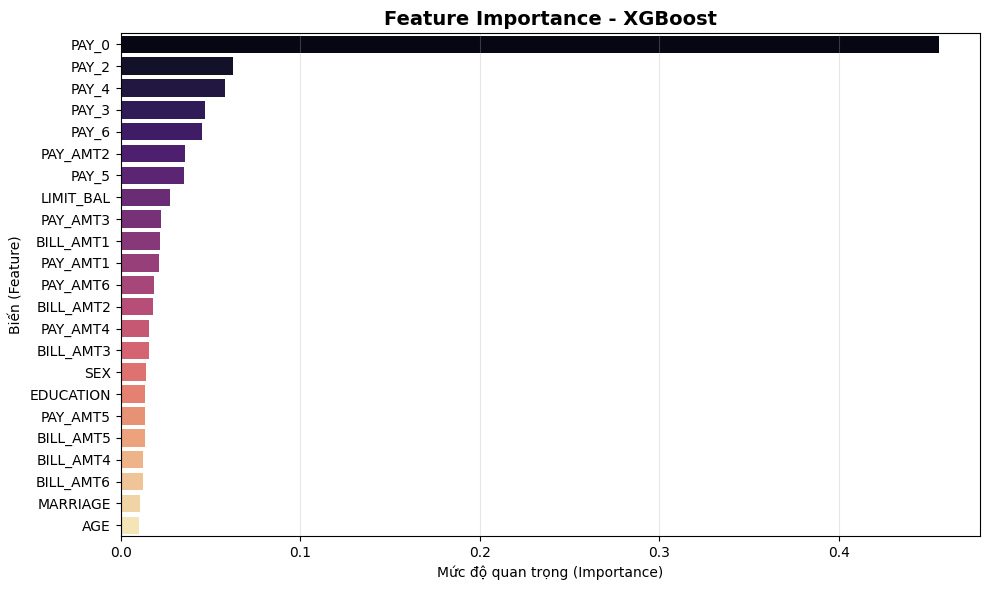

In [7]:
# 1. XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 2. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH
xgb = XGBClassifier(
    n_estimators=200,                       # số cây → học nhiều hơn
    learning_rate=0.05,                     # tốc độ học → học chậm hơn để tránh overfitting
    max_depth=4,                            # độ sâu cây → giảm overfit
    scale_pos_weight=scale_pos_weight,      # xử lý imbalance
    random_state=42,                        # đảm bảo chạy lại giống nhau
    use_label_encoder=False,                # tránh warning
    eval_metric='logloss'                   # metric dùng trong lúc học
)

xgb.fit(X_train, y_train)

# 3. ĐÁNH GIÁ MÔ HÌNH
# SỬA: Xóa bỏ y_pred, y_proba và các đoạn vẽ hình thủ công.
evaluate_model(xgb, X_test, y_test, "XGBoost")

# 4. MỞ RỘNG: VẼ FEATURE IMPORTANCE CỦA XGBOOST
# Trực quan hóa xem biến nào XGBoost coi là quan trọng nhất để dự báo nợ xấu
importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_xgb, palette='magma')
plt.title('Feature Importance - XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Mức độ quan trọng (Importance)')
plt.ylabel('Biến (Feature)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

8. ID3 (DECISION TREE)

[*] Đã tìm thấy độ sâu tối ưu (Best Depth): 12 với điểm Recall: 0.4230

============== ĐÁNH GIÁ MÔ HÌNH: DECISION TREE (ID3 - DEPTH 12) ==============
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      7009
           1       0.59      0.36      0.45      1991

    accuracy                           0.80      9000
   macro avg       0.71      0.65      0.66      9000
weighted avg       0.78      0.80      0.78      9000



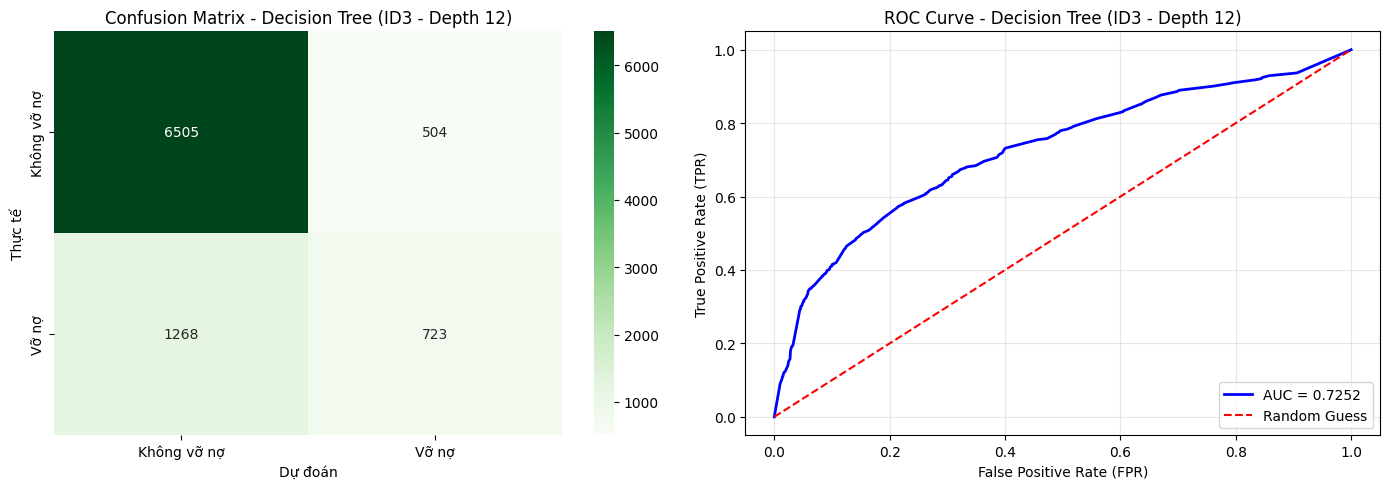

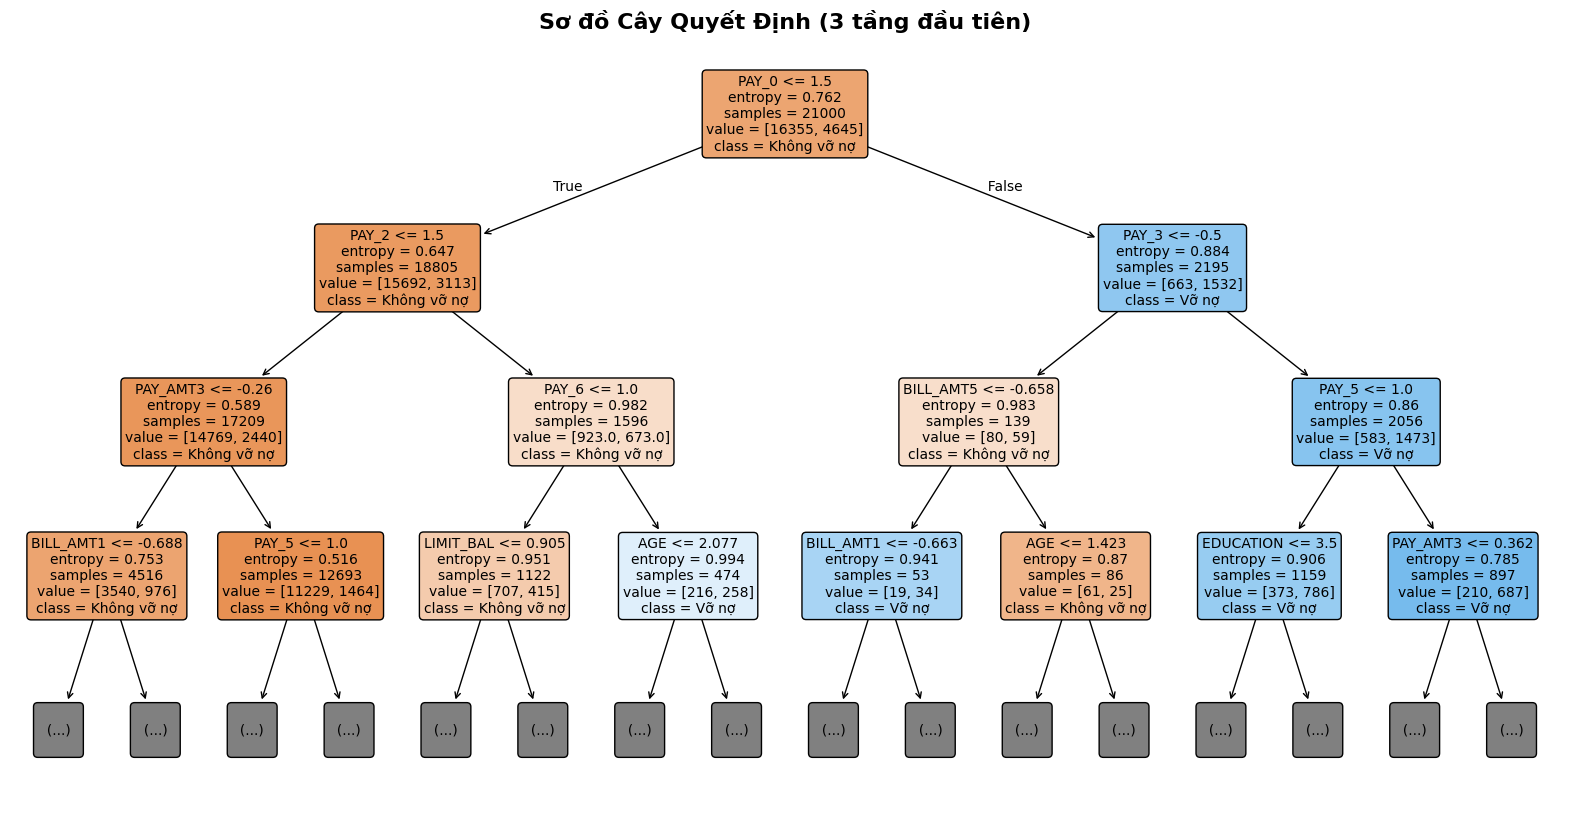

In [8]:
# 1. TÌM SIÊU THAM SỐ TỐT NHẤT (HYPERPARAMETER TUNING)
X_train_p, X_val, y_train_p, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

depths = [3, 5, 7, 10, 12, 15]
best_depth = 3
best_recall = 0

for d in depths:
    temp = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=d,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    )
    temp.fit(X_train_p, y_train_p)
    recall = recall_score(y_val, temp.predict(X_val))
    
    if recall > best_recall:
        best_recall = recall
        best_depth = d

print(f"[*] Đã tìm thấy độ sâu tối ưu (Best Depth): {best_depth} với điểm Recall: {best_recall:.4f}\n")

# 2. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH CHÍNH THỨC
model_id3 = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=best_depth,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
model_id3.fit(X_train, y_train)

# 3. ĐÁNH GIÁ MÔ HÌNH (Dùng hàm cỗ máy)
evaluate_model(model_id3, X_test, y_test, f"Decision Tree (ID3 - Depth {best_depth})")

# 4. VẼ CÂY QUYẾT ĐỊNH (Tùy chọn cho Slide)
plt.figure(figsize=(20, 10)) 
plot_tree(
    model_id3, 
    max_depth=3, 
    feature_names=X_train.columns, 
    class_names=["Không vỡ nợ", "Vỡ nợ"], 
    filled=True, 
    rounded=True,
    fontsize=10
)
plt.title(f'Sơ đồ Cây Quyết Định (3 tầng đầu tiên)', fontsize=16, fontweight='bold')
plt.show()

9. RANDOM FOREST

============== ĐÁNH GIÁ MÔ HÌNH: RANDOM FOREST ==============
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      7009
           1       0.51      0.58      0.54      1991

    accuracy                           0.78      9000
   macro avg       0.69      0.71      0.70      9000
weighted avg       0.79      0.78      0.79      9000



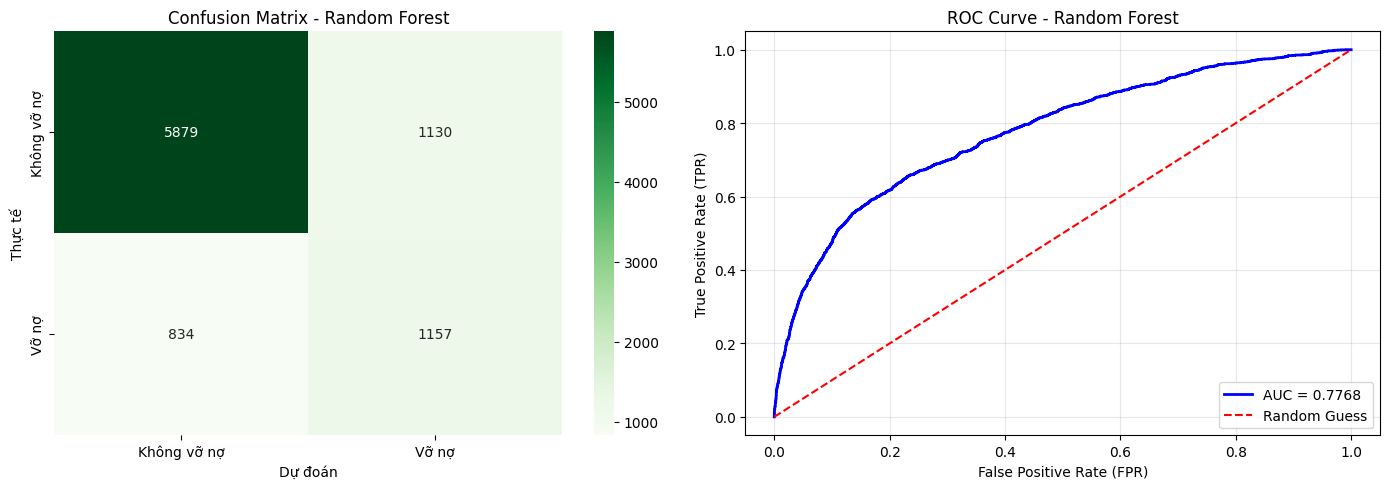

In [9]:
# 1. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH
model_rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    min_samples_split=20, 
    min_samples_leaf=10, 
    class_weight='balanced', 
    random_state=42
)
model_rf.fit(X_train, y_train)

# 2. ĐÁNH GIÁ MÔ HÌNH
evaluate_model(model_rf, X_test, y_test, "Random Forest")

10. KNN

[*] Đã tìm thấy K tối ưu: 7 với điểm Recall: 0.3972

============== ĐÁNH GIÁ MÔ HÌNH: KNN (K=7) ==============
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      7009
           1       0.59      0.35      0.44      1991

    accuracy                           0.80      9000
   macro avg       0.71      0.64      0.66      9000
weighted avg       0.78      0.80      0.78      9000



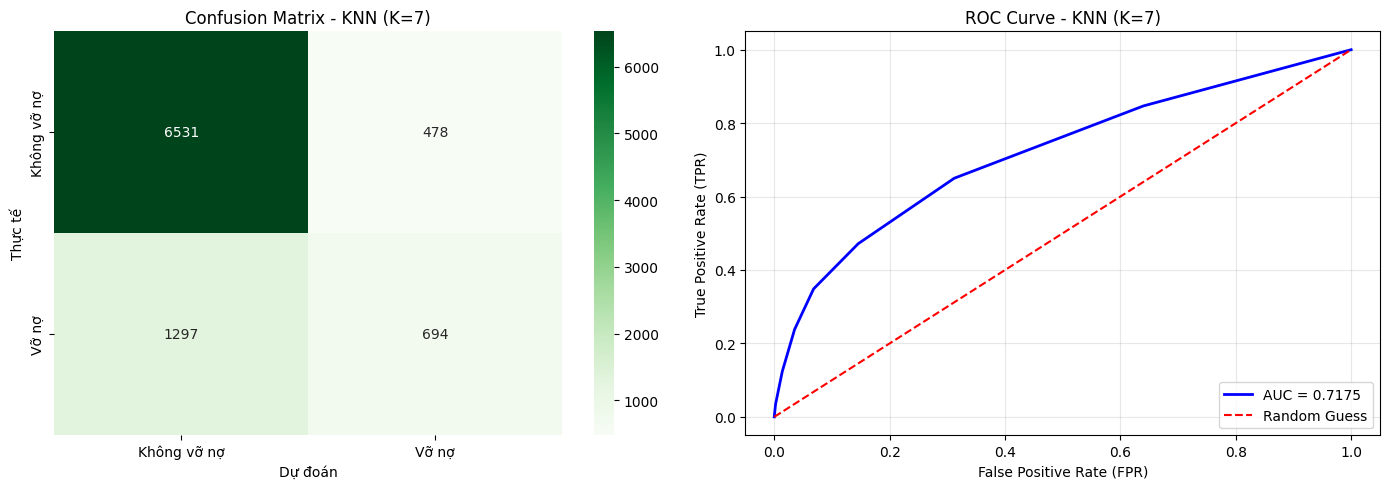

In [10]:
# 1. TÌM K TỐI ƯU (HYPERPARAMETER TUNING)
X_train_p, X_val, y_train_p, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

k_values = [5, 7, 9, 11]
best_k = 5
max_knn_rec = 0

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_p, y_train_p) # Học trên tập Train phụ
    k_rec = recall_score(y_val, knn_temp.predict(X_val)) # Dò điểm trên tập Validation
    
    if k_rec > max_knn_rec:
        max_knn_rec = k_rec
        best_k = k

print(f"[*] Đã tìm thấy K tối ưu: {best_k} với điểm Recall: {max_knn_rec:.4f}\n")

# 2. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH CHÍNH THỨC
# Dùng best_k vừa tìm được để học trên toàn bộ dữ liệu Train gốc
model_knn = KNeighborsClassifier(n_neighbors=best_k)
model_knn.fit(X_train, y_train)

# 3. ĐÁNH GIÁ MÔ HÌNH
evaluate_model(model_knn, X_test, y_test, f"KNN (K={best_k})")

11. Naive Bayes

--- KẾT QUẢ GÁN NHÃN 10 MẪU ĐẦU TIÊN ---
       AGE  LIMIT_BAL  Predicted_default  Probability_default
8941    30     230000                  0         2.857082e-01
17618   32      80000                  1         9.884787e-01
27895   29     100000                  0         3.639101e-07
16103   37      10000                  1         9.999996e-01
4422    34     110000                  0         3.911730e-01
3833    23     130000                  0         2.696617e-01
26189   37     250000                  0         2.271589e-04
25054   49      20000                  0         4.155250e-01
23468   39      50000                  1         9.999631e-01
11871   33      80000                  0         4.116621e-01


============== ĐÁNH GIÁ MÔ HÌNH: NAIVE BAYES ==============
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      7009
           1       0.43      0.58      0.49      1991

    accuracy                           0.74      90

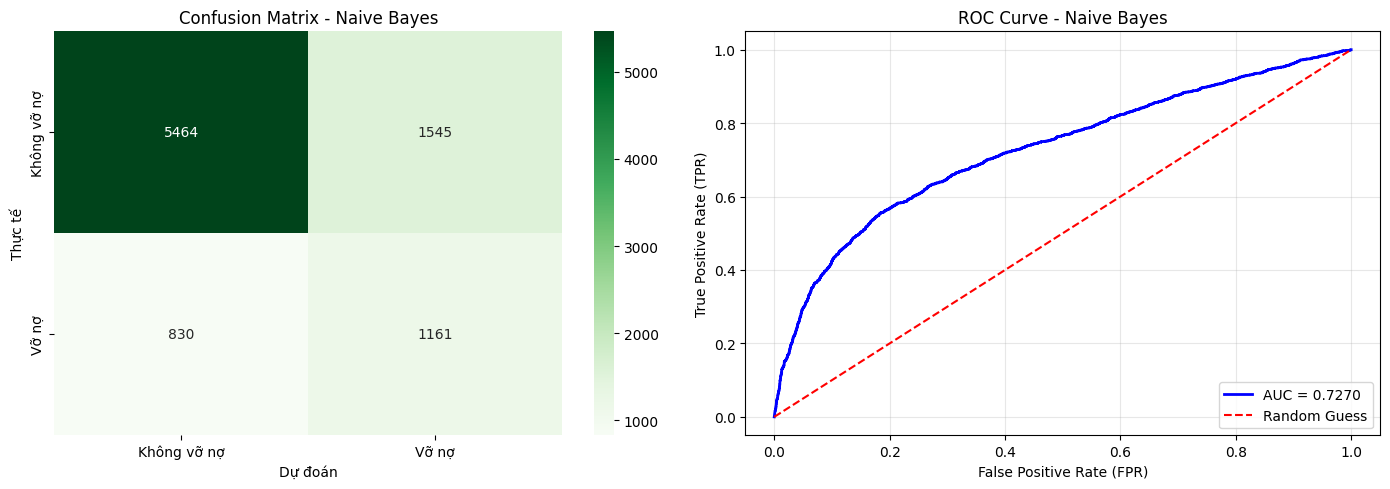

In [11]:
# 1. Khởi tạo và Huấn luyện mô hình
nb = GaussianNB()
nb.fit(X_train, y_train)

# 2. Dự đoán xác suất 
proba = nb.predict_proba(X_test)
threshold = 0.5
y_pred_nb = (proba[:,1] >= threshold).astype(int)

# Tạo bảng test_result từ test_df gốc 
# để giữ nguyên Tuổi và Tiền thật (chưa scale) cho dễ đọc
test_result = test_df.copy()

# Gắn kết quả vào bảng test_result
test_result["Predicted_default"] = y_pred_nb
test_result["Probability_default"] = proba[:,1]

# Hiển thị 10 dòng kết quả đầu tiên
print("--- KẾT QUẢ GÁN NHÃN 10 MẪU ĐẦU TIÊN ---")
print(test_result[["AGE", "LIMIT_BAL", "Predicted_default", "Probability_default"]].head(10))
print("\n")

# 3. ĐÁNH GIÁ MÔ HÌNH (Gọi cỗ máy đánh giá chung)
evaluate_model(nb, X_test, y_test, "Naive Bayes")

In [35]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    try:
        proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)
    except:
        auc = None

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC": auc
    }

models = {
    "Logistic Regression": logreg,
    "KNN": model_knn,
    "Naive Bayes": nb,
    "Decision Tree": model_id3,
    "Random Forest": model_rf,
    "XGBoost": xgb
}

results = []

for name, model in models.items():
    scores = evaluate_model(model, X_test, y_test)
    scores["Model"] = name
    results.append(scores)

df_results = pd.DataFrame(results)

In [38]:
df_results = df_results[["Model", "Accuracy", "Precision", "Recall", "F1-score", "AUC"]]
styled = (
    df_results.style
    .set_caption("BẢNG SO SÁNH HIỆU SUẤT MÔ HÌNH")

    .background_gradient(subset=["Accuracy"], cmap="Blues")
    .background_gradient(subset=["Precision"], cmap="Purples")
    .background_gradient(subset=["Recall"], cmap="Greens")
    .background_gradient(subset=["F1-score"], cmap="Oranges")
    .background_gradient(subset=["AUC"], cmap="Reds")

    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '18px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('font-size', '16px'), ('text-align', 'center')]},
        {'selector': 'caption', 'props': [
            ('font-size', '22px'),
            ('font-weight', 'bold'),
            ('text-align', 'center')
        ]}
    ])

    .set_properties(**{
        'padding': '10px',
        'min-width': '130px'
    })

    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "AUC": "{:.4f}"
    })
)
styled

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.6844,0.3735,0.6293,0.4688,0.7159
1,KNN,0.8028,0.5922,0.3486,0.4388,0.7175
2,Naive Bayes,0.7361,0.4290,0.5831,0.4944,0.7270
3,Decision Tree,0.8031,0.5892,0.3631,0.4493,0.7252
4,Random Forest,0.7818,0.5059,0.5811,0.5409,0.7768
5,XGBoost,0.7646,0.4754,0.6218,0.5388,0.7785


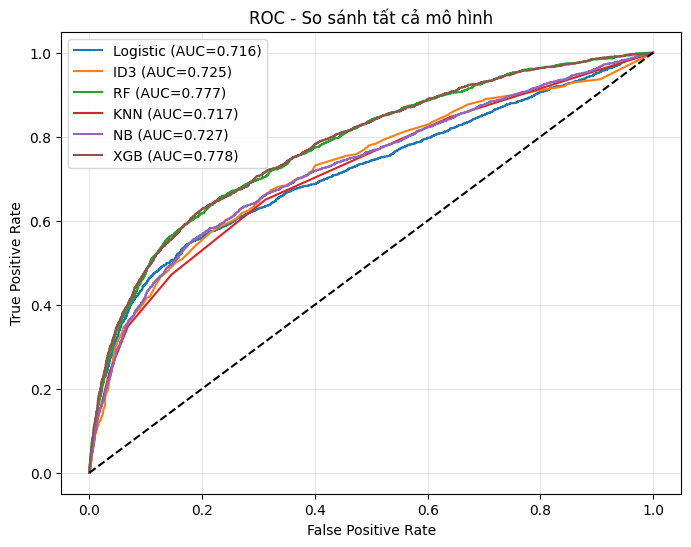

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

models = {
    "Logistic": logreg,
    "ID3": model_id3,
    "RF": model_rf,
    "KNN": model_knn,
    "NB": nb,
    "XGB": xgb
}

for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

# đường baseline
plt.plot([0,1], [0,1], 'k--')

# label + title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - So sánh tất cả mô hình")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
Trong bài toán dự đoán vỡ nợ thẻ tín dụng, mục tiêu quan trọng nhất là phát hiện đúng khách hàng có nguy cơ (class 1), do đó Recall là chỉ số then 
chốt. Tuy nhiên, để đánh giá toàn diện mô hình, cần kết hợp thêm Precision, F1-score và ROC AUC nhằm xem xét cả độ chính xác và khả năng phân biệt 
tổng thể.

- Logistic Regression đạt Recall cao nhất trong các mô hình thử nghiệm (0.6293), cho thấy khả năng phát hiện nợ xấu tốt. Tuy nhiên, Precision
thấp (0.3735) do dự đoán nhầm nhiều khách hàng không vỡ nợ. Nguyên nhân là mô hình chỉ học quan hệ tuyến tính trong khi dữ liệu tín dụng có nhiều 
tương tác phi tuyến. AUC ở mức trung bình (0.7159) cho thấy khả năng phân biệt chưa thực sự ổn định.

- Ngược lại, Decision Tree (ID3) có Accuracy cao nhất (0.8031) nhưng Recall rất thấp (0.3631), do dữ liệu mất cân bằng khiến mô hình thiên về lớp 
không vỡ nợ và dễ bị overfit vào majority class. KNN cũng có Recall thấp (0.3486) và AUC thấp (0.7175), do phụ thuộc vào khoảng cách và nhạy cảm với 
nhiễu trong không gian nhiều chiều. Naive Bayes đạt Recall trung bình (0.5831) nhưng bị hạn chế bởi giả định độc lập giữa các biến, không phù hợp với 
dữ liệu thực tế.

- Random Forest cải thiện đáng kể với Recall (0.5811) và AUC cao (0.7768), nhờ khả năng học các quan hệ phi tuyến thông qua nhiều cây quyết định. Mặc 
dù đã giảm overfitting, mô hình vẫn có thể chưa tối ưu hoàn toàn các trường hợp khó.

- XGBoost là mô hình tốt nhất khi đạt Recall cao (0.6218), F1-score cao (0.5388) và AUC cao nhất (0.7785). Nhờ cơ chế boosting, mô hình tập trung học
từ các sai lầm trước đó và xử lý tốt các trường hợp vỡ nợ phức tạp.

Xét trên biểu đồ ROC, XGBoost và Random Forest có đường cong nằm phía trên các mô hình khác trong hầu hết các ngưỡng, cho thấy khả năng phân biệt 
tốt và ổn định trên toàn bộ miền. Nhóm Naive Bayes và Decision Tree (ID3) có đường cong ở mức trung bình, phản ánh hiệu suất phân biệt chưa thực sự 
nổi bật. Trong khi đó, KNN có đường ROC thấp, cho thấy khả năng phân biệt kém hơn, còn Logistic Regression chỉ đạt hiệu quả tại một số ngưỡng nhất 
định nhưng không duy trì được sự ổn định trên toàn bộ miền. Nhìn chung, các mô hình ensemble cho thấy ưu thế rõ rệt về khả năng phân biệt so với các
mô hình còn lại.

Tóm lại, mặc dù Logistic Regression có Recall cao nhất, nhưng Precision thấp và AUC trung bình cho thấy hiệu suất không ổn định. XGBoost là lựa chọn 
tốt nhất khi xét tổng thể giữa Recall, F1-score và AUC, đặc biệt phù hợp khi cần cân bằng giữa phát hiện nợ xấu và kiểm soát rủi ro dự đoán sai.

In [40]:
import numpy as np
from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#  1. LẤY XÁC SUẤT 
proba = xgb.predict_proba(X_test)[:, 1]


#  2. BASELINE (THRESHOLD = 0.5) 
y_pred_05 = (proba >= 0.5).astype(int)

base_acc = accuracy_score(y_test, y_pred_05)
base_precision = precision_score(y_test, y_pred_05)
base_recall = recall_score(y_test, y_pred_05)
base_f1 = f1_score(y_test, y_pred_05)
base_auc = roc_auc_score(y_test, proba)


# = 3. PR CURVE 
precision, recall, thresholds = precision_recall_curve(y_test, proba)


# = 4. TÌM THRESHOLD TỐI ƯU 
best_threshold = 0.5
best_f1 = base_f1

# dùng i+1 để tránh lệch index
for i in range(len(thresholds)):
    p = precision[i + 1]
    r = recall[i + 1]

    f1_i = 2 * (p * r) / (p + r + 1e-8)

    # điều kiện thông minh:
    # - recall không giảm
    # - precision không giảm quá nhiều
    # - f1 tốt hơn
    if r >= base_recall and p >= base_precision - 0.05 and f1_i > best_f1:
        best_f1 = f1_i
        best_threshold = thresholds[i]


# 5. DỰ ĐOÁN VỚI THRESHOLD MỚI 
y_pred_best = (proba >= best_threshold).astype(int)

best_acc = accuracy_score(y_test, y_pred_best)
best_precision = precision_score(y_test, y_pred_best)
best_recall = recall_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best)


#  6. IN KẾT QUẢ 
print("=== BASELINE (Threshold = 0.5) ===")
print(f"Accuracy : {base_acc:.4f}")
print(f"Precision: {base_precision:.4f}")
print(f"Recall   : {base_recall:.4f}")
print(f"F1-score : {base_f1:.4f}")
print(f"AUC      : {base_auc:.4f}")

print("\n=== OPTIMIZED THRESHOLD ===")
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Accuracy : {best_acc:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall   : {best_recall:.4f}")
print(f"F1-score : {best_f1:.4f}")
print(f"AUC      : {base_auc:.4f}")  

=== BASELINE (Threshold = 0.5) ===
Accuracy : 0.7646
Precision: 0.4754
Recall   : 0.6218
F1-score : 0.5388
AUC      : 0.7785

=== OPTIMIZED THRESHOLD ===
Best Threshold: 0.5006
Accuracy : 0.7651
Precision: 0.4763
Recall   : 0.6218
F1-score : 0.5394
AUC      : 0.7785


In [ ]:
Sau khi tiến hành tối ưu threshold nhằm cải thiện hiệu suất mô hình, phương pháp được sử dụng là dựa trên đường cong Precision–Recall. Cụ thể, mô hình
được đánh giá trên toàn bộ các giá trị threshold có thể, sau đó lựa chọn ngưỡng tối ưu thỏa mãn các điều kiện: Recall không thấp hơn giá trị
baseline (tại threshold = 0.5), Precision không giảm quá mức cho phép, và F1-score đạt giá trị cao nhất. Cách tiếp cận này giúp đảm bảo vừa duy trì
khả năng phát hiện nợ xấu, vừa cải thiện sự cân bằng tổng thể của mô hình.
    
Kết quả cho thấy giá trị tối ưu (0.5006) gần như trùng với ngưỡng mặc định 0.5 và chỉ mang lại cải thiện rất nhỏ về Precision và F1-score, trong khi 
Recall và AUC không thay đổi đáng kể.

Điều này cho thấy, mặc dù việc tối ưu threshold có thể giúp tìm ra giá trị tốt nhất về mặt chỉ số, nhưng trong trường hợp này, mô hình XGBoost đã 
hoạt động gần tối ưu ngay từ đầu. Do đó, việc điều chỉnh threshold không tạo ra khác biệt đáng kể về hiệu suất.

Tuy nhiên, xét trên góc độ thực tế, việc tối ưu threshold vẫn rất quan trọng vì cho phép điều chỉnh mô hình theo mục tiêu kinh doanh. Cụ thể, có thể
giảm threshold để tăng khả năng phát hiện nợ xấu (tăng Recall) hoặc tăng threshold để hạn chế cảnh báo sai (tăng Precision). Do đó, threshold không 
chỉ nhằm tối ưu chỉ số mà còn là công cụ điều chỉnh mức chấp nhận rủi ro trong kinh doanh.

In [ ]:
FP-GROWTH

In [2]:
import pandas as pd
from collections import Counter
# Đọc dữ liệu transactions từ CSV
transactions_df = pd.read_csv('transactions_table.csv')
# Chuyển đổi thành danh sách các giao dịch (list of lists)
transactions = transactions_df.values.tolist()
# Đếm số lần xuất hiện của mỗi item
item_counts = Counter()
for transaction in transactions:
    item_counts.update(transaction)
# In ra item_counts
print("Số lần xuất hiện của các item:")
for item, count in item_counts.items():
    print(f"{item}: {count}")

Số lần xuất hiện của các item:
Medium_Limit: 9458
Middle_Aged: 12412
Female: 12675
Education_University: 9833
Marriage_Single: 11208
Pay_On_Time: 16189
Education_Graduate: 7379
Low_Limit: 7992
Young: 6736
Male: 8325
Marriage_Married: 9526
Pay_Delayed: 4811
High_Limit: 3550
Old: 1852
Education_High_School: 3440
Education_Others: 348
Marriage_Others: 266


In [46]:
# Loại bỏ item có support < 0.4 và in danh sách item giữ lại theo thứ tự giảm dần
import os
import pandas as pd

minsup = 0.4

# Load one-hot encoded matrix nếu có, ngược lại build từ transactions_table.csv
if os.path.exists('df_encoded.csv'):
    df = pd.read_csv('df_encoded.csv')
    df = df.loc[:, [c for c in df.columns if not str(c).startswith('Unnamed')]]
else:
    if not os.path.exists('transactions_table.csv'):
        raise FileNotFoundError('Không tìm thấy df_encoded.csv hoặc transactions_table.csv')
    df_raw = pd.read_csv('transactions_table.csv', header=0)
    transactions = []
    for _, row in df_raw.iterrows():
        items = [str(x).strip() for x in row.values if pd.notna(x) and str(x).strip()!='nan']
        transactions.append(items)
    items = sorted({it for t in transactions for it in t})
    df = pd.DataFrame(0, index=range(len(transactions)), columns=items)
    for i, t in enumerate(transactions):
        for it in t:
            df.at[i, it] = 1

# Tính support theo item (tỉ lệ giao dịch chứa item)
item_support = df.mean()

# Giữ các item có support >= minsup, sắp xếp giảm dần
kept = item_support[item_support >= minsup].sort_values(ascending=False)
removed = item_support[item_support < minsup].sort_values(ascending=False)

print(f'Kept {len(kept)} items, removed {len(removed)} items (minsup={minsup})')
print('Kept items (support desc):')
print(kept.to_string())

# Rút gọn DataFrame chỉ còn các cột được giữ
df_reduced = df[kept.index].copy()
print('DataFrame shape after dropping low-support items ->', df_reduced.shape)

# (Tùy chọn) lưu danh sách item giữ lại
kept.to_csv(f'kept_items_minsup{minsup:.2f}.csv', header=['support'])
print(f"Saved kept_items_minsup{minsup:.2f}.csv")

Kept 7 items, removed 10 items (minsup=0.4)
Kept items (support desc):
Pay_On_Time             0.770905
Female                  0.603571
Middle_Aged             0.591048
Marriage_Single         0.533714
Education_University    0.468238
Marriage_Married        0.453619
Medium_Limit            0.450381
DataFrame shape after dropping low-support items -> (21000, 7)
Saved kept_items_minsup0.40.csv


In [47]:
#XÂY CÂY T1
import pandas as pd
from graphviz import Digraph

# Đọc dữ liệu
df = pd.read_csv("df_encoded.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Tính support
supports = df.mean().sort_values(ascending=False)

# Lấy transaction T1
t1_items = [col for col in df.columns if df.loc[0, col] == 1]
t1_sorted = sorted(t1_items, key=lambda x: supports[x], reverse=True)

print("T1 gồm các cột:", " -> ".join(t1_sorted))

# Tạo node FP-Tree
class FPNode:
    def __init__(self, item, count=1):
        self.item = item
        self.count = count
        self.children = {}

    def add_child(self, item):
        if item not in self.children:
            self.children[item] = FPNode(item)
        else:
            self.children[item].count += 1
        return self.children[item]

# Xây cây T1
root = FPNode("ROOT", count=0)
current = root

for item in t1_sorted:
    current = current.add_child(item)

# Hàm vẽ cây
def add_nodes_edges(graph, node, parent_id=None, node_id=0):
    current_id = str(node_id)
    graph.node(current_id, f"{node.item}\n({node.count})")

    if parent_id is not None:
        graph.edge(parent_id, current_id)

    next_id = node_id + 1
    for child in node.children.values():
        next_id = add_nodes_edges(graph, child, current_id, next_id)

    return next_id

# Vẽ riêng cây T1, bỏ ROOT
dot = Digraph()
dot.attr(rankdir='TB')

for child in root.children.values():
    add_nodes_edges(dot, child)

dot


T1 gồm các cột: Pay_On_Time -> Female -> Middle_Aged -> Marriage_Single -> Education_University -> Medium_Limit


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [8]:
import pandas as pd
from graphviz import Digraph

# Đọc dữ liệu
df = pd.read_csv("df_encoded.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Tính support
supports = df.mean().sort_values(ascending=False)

# Lấy transaction T1
t1_items = [col for col in df.columns if df.loc[0, col] == 1]
t1_sorted = sorted(t1_items, key=lambda x: supports[x], reverse=True)

print("T1 gồm các cột:", " -> ".join(t1_sorted))

# Tạo node FP-Tree
class FPNode:
    def __init__(self, item, count=1):
        self.item = item
        self.count = count
        self.children = {}

    def add_child(self, item):
        if item not in self.children:
            self.children[item] = FPNode(item)
        else:
            self.children[item].count += 1
        return self.children[item]

# Xây cây T1
root = FPNode("ROOT", count=0)
current = root

for item in t1_sorted:
    current = current.add_child(item)

# Hàm vẽ cây
def add_nodes_edges(graph, node, parent_id=None, node_id=0):
    current_id = str(node_id)
    graph.node(current_id, f"{node.item}\n({node.count})")

    if parent_id is not None:
        graph.edge(parent_id, current_id)

    next_id = node_id + 1
    for child in node.children.values():
        next_id = add_nodes_edges(graph, child, current_id, next_id)

    return next_id

# Vẽ riêng cây T1, bỏ ROOT
dot = Digraph()
dot.attr(rankdir='TB')

for child in root.children.values():
    add_nodes_edges(dot, child)

dot


T1 gồm các cột: Pay_On_Time -> Female -> Middle_Aged -> Marriage_Single -> Education_University -> Medium_Limit


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [48]:
#CÂY T2
import pandas as pd
from graphviz import Digraph

# Đọc dữ liệu
df = pd.read_csv("df_encoded.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Tính support của từng item
supports = df.mean().sort_values(ascending=False)

# Lấy T1 và T2
t1_items = [col for col in df.columns if df.loc[0, col] == 1]
t2_items = [col for col in df.columns if df.loc[1, col] == 1]

# Sắp xếp theo support giảm dần
t1_sorted = sorted(t1_items, key=lambda x: supports[x], reverse=True)
t2_sorted = sorted(t2_items, key=lambda x: supports[x], reverse=True)

print("T1 gồm các cột:", " -> ".join(t1_sorted))
print("T2 gồm các cột:", " -> ".join(t2_sorted))

# Node của FP-Tree
class FPNode:
    def __init__(self, item, count=1):
        self.item = item
        self.count = count
        self.children = {}

    def add_child(self, item):
        if item not in self.children:
            self.children[item] = FPNode(item, count=1)
        else:
            self.children[item].count += 1
        return self.children[item]

# Hàm chèn 1 transaction vào cây
def insert_transaction(root, transaction):
    current = root
    for item in transaction:
        current = current.add_child(item)

# Tạo cây và chèn T1, rồi T2
root = FPNode("ROOT", count=0)
insert_transaction(root, t1_sorted)
insert_transaction(root, t2_sorted)

# Hàm thêm node và cạnh vào graphviz
def add_nodes_edges(graph, node, parent_id=None, node_id=0):
    current_id = str(node_id)
    graph.node(current_id, f"{node.item}\n({node.count})")

    if parent_id is not None:
        graph.edge(parent_id, current_id)

    next_id = node_id + 1
    for child in node.children.values():
        next_id = add_nodes_edges(graph, child, current_id, next_id)

    return next_id

# Vẽ cây sau khi có T1 và T2
dot = Digraph()
dot.attr(rankdir="TB")

for child in root.children.values():
    add_nodes_edges(dot, child)

dot


T1 gồm các cột: Pay_On_Time -> Female -> Middle_Aged -> Marriage_Single -> Education_University -> Medium_Limit
T2 gồm các cột: Pay_On_Time -> Female -> Middle_Aged -> Marriage_Single -> Medium_Limit -> Education_Graduate


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [49]:
#CÂY T3
import pandas as pd
from graphviz import Digraph

# Đọc dữ liệu
df = pd.read_csv("df_encoded.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Tính support từng item
supports = df.mean().sort_values(ascending=False)

# Lấy T1, T2, T3
t1_items = [col for col in df.columns if df.loc[0, col] == 1]
t2_items = [col for col in df.columns if df.loc[1, col] == 1]
t3_items = [col for col in df.columns if df.loc[2, col] == 1]

# Sắp xếp theo support giảm dần
t1_sorted = sorted(t1_items, key=lambda x: supports[x], reverse=True)
t2_sorted = sorted(t2_items, key=lambda x: supports[x], reverse=True)
t3_sorted = sorted(t3_items, key=lambda x: supports[x], reverse=True)

print("T1 gồm các cột:", " -> ".join(t1_sorted))
print("T2 gồm các cột:", " -> ".join(t2_sorted))
print("T3 gồm các cột:", " -> ".join(t3_sorted))

# Node FP-Tree
class FPNode:
    def __init__(self, item, count=1):
        self.item = item
        self.count = count
        self.children = {}

    def add_child(self, item):
        if item not in self.children:
            self.children[item] = FPNode(item, count=1)
        else:
            self.children[item].count += 1
        return self.children[item]

# Hàm chèn transaction
def insert_transaction(root, transaction):
    current = root
    for item in transaction:
        current = current.add_child(item)

# Tạo cây và chèn T1, T2, T3
root = FPNode("ROOT", count=0)
insert_transaction(root, t1_sorted)
insert_transaction(root, t2_sorted)
insert_transaction(root, t3_sorted)

# Hàm vẽ cây
def add_nodes_edges(graph, node, parent_id=None, node_id=0):
    current_id = str(node_id)
    graph.node(current_id, f"{node.item}\n({node.count})")

    if parent_id is not None:
        graph.edge(parent_id, current_id)

    next_id = node_id + 1
    for child in node.children.values():
        next_id = add_nodes_edges(graph, child, current_id, next_id)

    return next_id

# Vẽ cây sau khi có T1, T2, T3
dot = Digraph()
dot.attr(rankdir="TB")

for child in root.children.values():
    add_nodes_edges(dot, child)

dot


T1 gồm các cột: Pay_On_Time -> Female -> Middle_Aged -> Marriage_Single -> Education_University -> Medium_Limit
T2 gồm các cột: Pay_On_Time -> Female -> Middle_Aged -> Marriage_Single -> Medium_Limit -> Education_Graduate
T3 gồm các cột: Pay_On_Time -> Marriage_Single -> Male -> Low_Limit -> Education_Graduate -> Young


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [11]:
print("T1 gồm các cột:", " -> ".join(t1_sorted))
print("T2 gồm các cột:", " -> ".join(t2_sorted))
print("T3 gồm các cột:", " -> ".join(t3_sorted))


T1 gồm các cột: Pay_On_Time -> Female -> Middle_Aged -> Marriage_Single -> Education_University -> Medium_Limit
T2 gồm các cột: Pay_On_Time -> Female -> Middle_Aged -> Marriage_Single -> Medium_Limit -> Education_Graduate
T3 gồm các cột: Pay_On_Time -> Marriage_Single -> Male -> Low_Limit -> Education_Graduate -> Young


In [50]:
# Vẽ FP-Tree (hiển thị cấu trúc cây)
class FPNode:
    def __init__(self, item, count, parent):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.node_link = None

def create_header_table(frequent_items):
    header_table = {}
    for item in frequent_items:
        header_table[item] = None
    return header_table

def update_header_table(header_table, node):
    if header_table[node.item] is None:
        header_table[node.item] = node
    else:
        current = header_table[node.item]
        while current.node_link is not None:
            current = current.node_link
        current.node_link = node

def build_fp_tree(transactions, min_support, item_counts):
    # Get frequent items
    frequent_items = {item for item, count in item_counts.items() if count > min_support}
    # Sort frequent items by count descending
    frequent_items_sorted = sorted(frequent_items, key=lambda x: item_counts[x], reverse=True)
    # Create header table
    header_table = create_header_table(frequent_items)
    # Create root
    root = FPNode(None, 0, None)
    for transaction in transactions:
        # Filter and sort transaction
        filtered_transaction = [item for item in transaction if item in frequent_items]
        sorted_transaction = sorted(filtered_transaction, key=lambda x: item_counts[x], reverse=True)
        if not sorted_transaction:
            continue
        current_node = root
        for item in sorted_transaction:
            if item not in current_node.children:
                new_node = FPNode(item, 1, current_node)
                current_node.children[item] = new_node
                update_header_table(header_table, new_node)
            else:
                current_node.children[item].count += 1
            current_node = current_node.children[item]
    return root, header_table

def display_tree_detailed(node, indent=0, prefix=""):
    if node.item is not None:
        print('  ' * indent + prefix + f'{node.item}:{node.count}')
        prefix = "├── "
    else:
        prefix = ""
    children = list(node.children.values())
    for i, child in enumerate(children):
        if i == len(children) - 1:
            display_tree_detailed(child, indent + 1, "└── ")
        else:
            display_tree_detailed(child, indent + 1, "├── ")

# Build the tree with min_support
min_support = int(len(transactions) * 0.4) + 1  # for minsup > 0.4
root, header_table = build_fp_tree(transactions, min_support, item_counts)
print("Cấu trúc FP-Tree:")
display_tree_detailed(root)

Cấu trúc FP-Tree:
  ├── Pay_On_Time:16189
    ├── Female:9906
      ├── Middle_Aged:5755
        ├── Marriage_Single:2266
          ├── Education_University:934
            └── Medium_Limit:510
          └── Medium_Limit:757
        ├── Education_University:1817
          ├── Marriage_Married:1783
            └── Medium_Limit:941
          └── Medium_Limit:14
        ├── Marriage_Married:1627
          └── Medium_Limit:858
        └── Medium_Limit:18
      ├── Education_University:641
        ├── Marriage_Married:620
          └── Medium_Limit:279
        └── Medium_Limit:9
      ├── Marriage_Single:2984
        ├── Medium_Limit:772
        └── Education_University:1330
          └── Medium_Limit:546
      ├── Marriage_Married:502
        └── Medium_Limit:207
      └── Medium_Limit:6
    ├── Marriage_Single:1661
      ├── Education_University:752
        └── Medium_Limit:240
      └── Medium_Limit:359
    ├── Middle_Aged:3935
      ├── Education_University:988
        ├── Marriage_Marr

In [51]:
# Code riêng để khai thác tập phổ biến của item "Medium_Limit" sau khi xây cây xong

# Hàm tìm conditional pattern base cho một item
def find_prefix_path(header_table, target_item):
    conditional_patterns = []
    if target_item not in header_table:
        return conditional_patterns

    node = header_table[target_item]
    while node is not None:
        path = []
        current = node.parent
        while current.item is not None:
            path.append(current.item)
            current = current.parent
        if path:
            conditional_patterns.append((path[::-1], node.count))
        node = node.node_link
    return conditional_patterns

# Hàm xây dựng conditional FP tree
def build_conditional_fp_tree(conditional_patterns, min_support):
    # Tạo item_counts từ conditional_patterns
    item_counts_local = {}
    for path, count in conditional_patterns:
        for item in path:
            item_counts_local[item] = item_counts_local.get(item, 0) + count

    # Lọc frequent items
    frequent_items = {item for item, count in item_counts_local.items() if count >= min_support}
    frequent_items_sorted = sorted(frequent_items, key=lambda x: item_counts_local[x], reverse=True)

    # Header table cho conditional tree
    conditional_header = {item: None for item in frequent_items}

    # Root của conditional tree
    conditional_root = FPNode(None, 0, None)

    for path, count in conditional_patterns:
        # Lọc và sắp xếp path
        filtered_path = [item for item in path if item in frequent_items]
        sorted_path = sorted(filtered_path, key=lambda x: item_counts_local[x], reverse=True)
        if not sorted_path:
            continue

        current_node = conditional_root
        for item in sorted_path:
            if item not in current_node.children:
                new_node = FPNode(item, count, current_node)
                current_node.children[item] = new_node
                # Update header
                if conditional_header[item] is None:
                    conditional_header[item] = new_node
                else:
                    current = conditional_header[item]
                    while current.node_link is not None:
                        current = current.node_link
                    current.node_link = new_node
            else:
                current_node.children[item].count += count
            current_node = current_node.children[item]

    return conditional_root, conditional_header

# Hàm khai thác FP tree đệ quy
def mine_fp_tree(header_table, min_support, prefix, frequent_itemsets):
    # Sắp xếp items theo support tăng dần (từ ít frequent nhất)
    items = sorted(header_table.keys(), key=lambda x: item_counts[x])

    for item in items:
        # Thêm itemset mới
        new_prefix = prefix + [item]
        frequent_itemsets.append((new_prefix, item_counts[item]))

        # Tìm conditional pattern base
        conditional_patterns = find_prefix_path(header_table, item)

        # Xây conditional tree
        conditional_tree, conditional_header = build_conditional_fp_tree(conditional_patterns, min_support)

        # Đệ quy nếu conditional_header không rỗng
        if conditional_header:
            mine_fp_tree(conditional_header, min_support, new_prefix, frequent_itemsets)

target_item = "Medium_Limit"

# Giả sử cây đã được xây và header_table có sẵn từ cell trước

# Tìm conditional pattern base
conditional_patterns = find_prefix_path(header_table, target_item)

print(f"Conditional patterns cho '{target_item}':")
for path, count in conditional_patterns:
    print(f"{path}: {count}")

# Xây conditional FP tree
conditional_tree, conditional_header = build_conditional_fp_tree(conditional_patterns, min_support)

if conditional_header:
    # Mine conditional tree
    conditional_itemsets = []
    mine_fp_tree(conditional_header, min_support, [], conditional_itemsets)

    # Thêm target_item
    full_itemsets = []
    for itemset, support in conditional_itemsets:
        full_itemset = [target_item] + itemset
        full_itemsets.append((full_itemset, support))
    full_itemsets.append(([target_item], item_counts[target_item]))

    print(f"Tập phổ biến chứa '{target_item}':")
    for itemset, support in full_itemsets:
        print(f"{itemset}: {support}")
else:
    print(f"Chỉ có itemset đơn: {target_item} với support {item_counts[target_item]}")

# Sinh luật kết hợp với min_conf = 0.4
min_conf = 0.4
rules = []

if conditional_header:
    for itemset, support in full_itemsets:
        if len(itemset) > 1:  # itemset chứa target_item và ít nhất 1 item khác
            for item in itemset:
                if item != target_item:
                    antecedent = [item]
                    consequent = [target_item]
                    conf = support / item_counts[item]
                    if conf >= min_conf:
                        lift = conf / (item_counts[target_item] / len(transactions))
                        rules.append((antecedent, consequent, support, conf, lift))
else:
    # Nếu chỉ có itemset đơn, không có luật
    pass

print(f"\nLuật kết hợp với consequent '{target_item}' và min_conf >= {min_conf}:")
for ant, cons, supp, conf, lift in rules:
    print(f"{ant} => {cons} (support: {supp}, confidence: {conf:.2f}, lift: {lift:.2f})")

Conditional patterns cho 'Medium_Limit':
['Pay_On_Time', 'Female', 'Middle_Aged', 'Marriage_Single', 'Education_University']: 510
['Pay_On_Time', 'Female', 'Middle_Aged', 'Marriage_Single']: 757
['Middle_Aged', 'Marriage_Single', 'Education_University']: 73
['Pay_On_Time', 'Female', 'Marriage_Single']: 772
['Pay_On_Time', 'Female', 'Education_University', 'Marriage_Married']: 279
['Middle_Aged', 'Marriage_Single']: 140
['Pay_On_Time', 'Middle_Aged', 'Marriage_Single']: 531
['Marriage_Married']: 46
['Pay_On_Time', 'Female', 'Middle_Aged', 'Education_University', 'Marriage_Married']: 941
['Pay_On_Time', 'Female', 'Marriage_Single', 'Education_University']: 546
['Female', 'Marriage_Single', 'Education_University']: 131
['Pay_On_Time', 'Marriage_Single']: 359
['Middle_Aged', 'Marriage_Married']: 162
['Pay_On_Time', 'Middle_Aged', 'Marriage_Married']: 537
['Pay_On_Time', 'Middle_Aged', 'Marriage_Single', 'Education_University']: 303
['Female', 'Middle_Aged', 'Marriage_Married']: 235
['Femal

In [52]:
# Khai thác tập phổ biến cho item 'Medium_Limit' sau khi đã có conditional pattern base
# Giả sử đã có biến conditional_patterns chứa các pattern và count tương ứng

from itertools import combinations

# Bước 1: Đếm lại số lần xuất hiện của từng item trong conditional_patterns
item_counts_local = {}
for path, count in conditional_patterns:
    for item in path:
        item_counts_local[item] = item_counts_local.get(item, 0) + count

# Bước 2: Lọc các item có minsup >= 0.4
minsup = 0.4
num_trans = sum(count for _, count in conditional_patterns)
min_support_count = int(minsup * num_trans)
frequent_items = {item: cnt for item, cnt in item_counts_local.items() if cnt >= min_support_count}

print("Các item phổ biến với minsup >= 0.4:")
for item, cnt in frequent_items.items():
    print(f"{item}: {cnt}")

# Bước 3: Tìm tập phổ biến (frequent itemsets) chứa 'Medium_Limit'
frequent_itemsets = []
for item, cnt in frequent_items.items():
    frequent_itemsets.append((['Medium_Limit', item], cnt))

# Nếu muốn tìm tập phổ biến lớn hơn, có thể kết hợp các item phổ biến lại
items = list(frequent_items.keys())
for r in range(2, len(items)+1):
    for comb in combinations(items, r):
        # Đếm support của tập này trong conditional_patterns
        support = 0
        for path, count in conditional_patterns:
            if all(it in path for it in comb):
                support += count
        if support >= min_support_count:
            frequent_itemsets.append((['Medium_Limit'] + list(comb), support))

print("\nTập phổ biến chứa 'Medium_Limit':")
for itemset, support in frequent_itemsets:
    print(f"{itemset}: {support}")

Các item phổ biến với minsup >= 0.4:
Pay_On_Time: 7580
Female: 6077
Middle_Aged: 6122
Marriage_Single: 4903
Education_University: 4187
Marriage_Married: 4471

Tập phổ biến chứa 'Medium_Limit':
['Medium_Limit', 'Pay_On_Time']: 7580
['Medium_Limit', 'Female']: 6077
['Medium_Limit', 'Middle_Aged']: 6122
['Medium_Limit', 'Marriage_Single']: 4903
['Medium_Limit', 'Education_University']: 4187
['Medium_Limit', 'Marriage_Married']: 4471
['Medium_Limit', 'Pay_On_Time', 'Female']: 4917
['Medium_Limit', 'Pay_On_Time', 'Middle_Aged']: 4888
['Medium_Limit', 'Pay_On_Time', 'Marriage_Single']: 4018
['Medium_Limit', 'Female', 'Middle_Aged']: 3826


In [53]:
# Tìm conditional pattern base cho 'Education_University'
target_item = 'Education_University'
conditional_patterns_eu = find_prefix_path(header_table, target_item)

print(f"Conditional patterns cho '{target_item}':")
for path, count in conditional_patterns_eu:
    print(f"{path}: {count}")

# Khai thác tập phổ biến cho item 'Education_University' sau khi đã có conditional pattern base
from itertools import combinations

# Đếm lại số lần xuất hiện của từng item trong conditional_patterns_eu
item_counts_local_eu = {}
for path, count in conditional_patterns_eu:
    for item in path:
        item_counts_local_eu[item] = item_counts_local_eu.get(item, 0) + count

# Lọc các item có minsup >= 0.4
minsup = 0.4
num_trans_eu = sum(count for _, count in conditional_patterns_eu)
min_support_count_eu = int(minsup * num_trans_eu)
frequent_items_eu = {item: cnt for item, cnt in item_counts_local_eu.items() if cnt >= min_support_count_eu}

print("Các item phổ biến với minsup >= 0.4 cho 'Education_University':")
for item, cnt in frequent_items_eu.items():
    print(f"{item}: {cnt}")

# Tìm tập phổ biến (frequent itemsets) chứa 'Education_University'
frequent_itemsets_eu = []
for item, cnt in frequent_items_eu.items():
    frequent_itemsets_eu.append(([target_item, item], cnt))

# Nếu muốn tìm tập phổ biến lớn hơn, có thể kết hợp các item phổ biến lại
items_eu = list(frequent_items_eu.keys())
for r in range(2, len(items_eu)+1):
    for comb in combinations(items_eu, r):
        # Đếm support của tập này trong conditional_patterns_eu
        support = 0
        for path, count in conditional_patterns_eu:
            if all(it in path for it in comb):
                support += count
        if support >= min_support_count_eu:
            frequent_itemsets_eu.append(([target_item] + list(comb), support))

print("\nTập phổ biến chứa 'Education_University':")
for itemset, support in frequent_itemsets_eu:
    print(f"{itemset}: {support}")

Conditional patterns cho 'Education_University':
['Pay_On_Time', 'Female', 'Middle_Aged', 'Marriage_Single']: 934
['Pay_On_Time', 'Female']: 641
['Middle_Aged', 'Marriage_Single']: 218
['Pay_On_Time', 'Middle_Aged']: 988
['Pay_On_Time', 'Female', 'Marriage_Single']: 1330
['Female', 'Middle_Aged']: 518
['Pay_On_Time', 'Female', 'Middle_Aged']: 1817
['Pay_On_Time', 'Marriage_Single']: 752
['Female']: 220
['Female', 'Marriage_Single']: 406
['Pay_On_Time', 'Middle_Aged', 'Marriage_Single']: 743
['Marriage_Single']: 339
['Middle_Aged']: 331
['Female', 'Middle_Aged', 'Marriage_Single']: 208
['Pay_On_Time']: 295
Các item phổ biến với minsup >= 0.4 cho 'Education_University':
Pay_On_Time: 7500
Female: 6074
Middle_Aged: 5757
Marriage_Single: 4930

Tập phổ biến chứa 'Education_University':
['Education_University', 'Pay_On_Time']: 7500
['Education_University', 'Female']: 6074
['Education_University', 'Middle_Aged']: 5757
['Education_University', 'Marriage_Single']: 4930
['Education_University', '

In [54]:
# --- Tìm conditional pattern base cho 'Female' ---
target_item = 'Female'
conditional_patterns_female = find_prefix_path(header_table, target_item)

print(f"Conditional patterns cho '{target_item}':")
for path, count in conditional_patterns_female:
    print(f"{path}: {count}")

# --- Lọc item phổ biến với minsup >= 0.4 ---
item_counts_local_female = {}
for path, count in conditional_patterns_female:
    for item in path:
        item_counts_local_female[item] = item_counts_local_female.get(item, 0) + count

minsup = 0.4
num_trans_female = sum(count for _, count in conditional_patterns_female)
min_support_count_female = int(minsup * num_trans_female)
frequent_items_female = {item: cnt for item, cnt in item_counts_local_female.items() if cnt >= min_support_count_female}

print("Các item phổ biến với minsup >= 0.4 cho 'Female':")
for item, cnt in frequent_items_female.items():
    print(f"{item}: {cnt}")

# --- Tìm tập phổ biến (frequent itemsets) chứa 'Female' ---
from itertools import combinations
frequent_itemsets_female = []
for item, cnt in frequent_items_female.items():
    frequent_itemsets_female.append(([target_item, item], cnt))
items_female = list(frequent_items_female.keys())
for r in range(2, len(items_female)+1):
    for comb in combinations(items_female, r):
        support = 0
        for path, count in conditional_patterns_female:
            if all(it in path for it in comb):
                support += count
        if support >= min_support_count_female:
            frequent_itemsets_female.append(([target_item] + list(comb), support))
print("\nTập phổ biến chứa 'Female':")
for itemset, support in frequent_itemsets_female:
    print(f"{itemset}: {support}")

Conditional patterns cho 'Female':
['Pay_On_Time']: 9906
Các item phổ biến với minsup >= 0.4 cho 'Female':
Pay_On_Time: 9906

Tập phổ biến chứa 'Female':
['Female', 'Pay_On_Time']: 9906


In [18]:
# --- Tìm conditional pattern base cho 'Middle_Aged' ---
target_item = 'Middle_Aged'
conditional_patterns_ma = find_prefix_path(header_table, target_item)

print(f"Conditional patterns cho '{target_item}':")
for path, count in conditional_patterns_ma:
    print(f"{path}: {count}")

# --- Lọc item phổ biến với minsup >= 0.4 ---
item_counts_local_ma = {}
for path, count in conditional_patterns_ma:
    for item in path:
        item_counts_local_ma[item] = item_counts_local_ma.get(item, 0) + count

minsup = 0.4
num_trans_ma = sum(count for _, count in conditional_patterns_ma)
min_support_count_ma = int(minsup * num_trans_ma)
frequent_items_ma = {item: cnt for item, cnt in item_counts_local_ma.items() if cnt >= min_support_count_ma}

print("Các item phổ biến với minsup >= 0.4 cho 'Middle_Aged':")
for item, cnt in frequent_items_ma.items():
    print(f"{item}: {cnt}")

# --- Tìm tập phổ biến (frequent itemsets) chứa 'Middle_Aged' ---
from itertools import combinations
frequent_itemsets_ma = []
for item, cnt in frequent_items_ma.items():
    frequent_itemsets_ma.append(([target_item, item], cnt))
items_ma = list(frequent_items_ma.keys())
for r in range(2, len(items_ma)+1):
    for comb in combinations(items_ma, r):
        support = 0
        for path, count in conditional_patterns_ma:
            if all(it in path for it in comb):
                support += count
        if support >= min_support_count_ma:
            frequent_itemsets_ma.append(([target_item] + list(comb), support))
print("\nTập phổ biến chứa 'Middle_Aged':")
for itemset, support in frequent_itemsets_ma:
    print(f"{itemset}: {support}")

Conditional patterns cho 'Middle_Aged':
['Pay_On_Time', 'Female']: 5755
['Pay_On_Time']: 3935
['Female']: 1510
Các item phổ biến với minsup >= 0.4 cho 'Middle_Aged':
Pay_On_Time: 9690
Female: 7265

Tập phổ biến chứa 'Middle_Aged':
['Middle_Aged', 'Pay_On_Time']: 9690
['Middle_Aged', 'Female']: 7265
['Middle_Aged', 'Pay_On_Time', 'Female']: 5755


In [55]:
# Lọc item và tìm tập phổ biến cho 'Marriage_Single'
from itertools import combinations

target_item = 'Marriage_Single'
conditional_patterns_ms = find_prefix_path(header_table, target_item)

# Đếm lại số lần xuất hiện của từng item trong conditional_patterns_ms
item_counts_local_ms = {}
for path, count in conditional_patterns_ms:
    for item in path:
        item_counts_local_ms[item] = item_counts_local_ms.get(item, 0) + count

# Lọc các item có minsup >= 0.4
minsup = 0.4
num_trans_ms = sum(count for _, count in conditional_patterns_ms)
min_support_count_ms = int(minsup * num_trans_ms)
frequent_items_ms = {item: cnt for item, cnt in item_counts_local_ms.items() if cnt >= min_support_count_ms}

print("Các item phổ biến với minsup >= 0.4 cho 'Marriage_Single':")
for item, cnt in frequent_items_ms.items():
    print(f"{item}: {cnt}")

# Tìm tập phổ biến (frequent itemsets) chứa 'Marriage_Single'
frequent_itemsets_ms = []
for item, cnt in frequent_items_ms.items():
    frequent_itemsets_ms.append(([target_item, item], cnt))

# Nếu muốn tìm tập phổ biến lớn hơn, có thể kết hợp các item phổ biến lại
items_ms = list(frequent_items_ms.keys())
for r in range(2, len(items_ms)+1):
    for comb in combinations(items_ms, r):
        # Đếm support của tập này trong conditional_patterns_ms
        support = 0
        for path, count in conditional_patterns_ms:
            if all(it in path for it in comb):
                support += count
        if support >= min_support_count_ms:
            frequent_itemsets_ms.append(([target_item] + list(comb), support))

print("\nTập phổ biến chứa 'Marriage_Single':")
for itemset, support in frequent_itemsets_ms:
    print(f"{itemset}: {support}")

Các item phổ biến với minsup >= 0.4 cho 'Marriage_Single':
Pay_On_Time: 8731
Female: 6604
Middle_Aged: 5119

Tập phổ biến chứa 'Marriage_Single':
['Marriage_Single', 'Pay_On_Time']: 8731
['Marriage_Single', 'Female']: 6604
['Marriage_Single', 'Middle_Aged']: 5119
['Marriage_Single', 'Pay_On_Time', 'Female']: 5250


In [56]:
# Tìm conditional pattern base cho 'Marriage_Married'
target_item = 'Marriage_Married'
conditional_patterns_mm = find_prefix_path(header_table, target_item)

print(f"Conditional patterns cho '{target_item}':")
for path, count in conditional_patterns_mm:
    print(f"{path}: {count}")

Conditional patterns cho 'Marriage_Married':
['Pay_On_Time', 'Female', 'Education_University']: 620
['Pay_On_Time', 'Middle_Aged', 'Education_University']: 965
['Female', 'Middle_Aged', 'Education_University']: 506
['Female', 'Middle_Aged']: 469
['Pay_On_Time', 'Female', 'Middle_Aged', 'Education_University']: 1783
['Female', 'Education_University']: 215
['Middle_Aged']: 350
['Pay_On_Time', 'Middle_Aged']: 1102
['Pay_On_Time', 'Female', 'Middle_Aged']: 1627
['Education_University']: 90
['Middle_Aged', 'Education_University']: 326
['Pay_On_Time', 'Education_University']: 285
['Pay_On_Time', 'Female']: 502
['Pay_On_Time']: 374
['Female']: 186


In [57]:
# Lọc item và tìm tập phổ biến cho 'Marriage_Married'
from itertools import combinations

target_item = 'Marriage_Married'
conditional_patterns_mm = find_prefix_path(header_table, target_item)

# Đếm lại số lần xuất hiện của từng item trong conditional_patterns_mm
item_counts_local_mm = {}
for path, count in conditional_patterns_mm:
    for item in path:
        item_counts_local_mm[item] = item_counts_local_mm.get(item, 0) + count

# Lọc các item có minsup >= 0.4
minsup = 0.4
num_trans_mm = sum(count for _, count in conditional_patterns_mm)
min_support_count_mm = int(minsup * num_trans_mm)
frequent_items_mm = {item: cnt for item, cnt in item_counts_local_mm.items() if cnt >= min_support_count_mm}

print("Các item phổ biến với minsup >= 0.4 cho 'Marriage_Married':")
for item, cnt in frequent_items_mm.items():
    print(f"{item}: {cnt}")

# Tìm tập phổ biến (frequent itemsets) chứa 'Marriage_Married'
frequent_itemsets_mm = []
for item, cnt in frequent_items_mm.items():
    frequent_itemsets_mm.append(([target_item, item], cnt))

# Nếu muốn tìm tập phổ biến lớn hơn, có thể kết hợp các item phổ biến lại
items_mm = list(frequent_items_mm.keys())
for r in range(2, len(items_mm)+1):
    for comb in combinations(items_mm, r):
        # Đếm support của tập này trong conditional_patterns_mm
        support = 0
        for path, count in conditional_patterns_mm:
            if all(it in path for it in comb):
                support += count
        if support >= min_support_count_mm:
            frequent_itemsets_mm.append(([target_item] + list(comb), support))

print("\nTập phổ biến chứa 'Marriage_Married':")
for itemset, support in frequent_itemsets_mm:
    print(f"{itemset}: {support}")

Các item phổ biến với minsup >= 0.4 cho 'Marriage_Married':
Pay_On_Time: 7258
Female: 5908
Education_University: 4790
Middle_Aged: 7128

Tập phổ biến chứa 'Marriage_Married':
['Marriage_Married', 'Pay_On_Time']: 7258
['Marriage_Married', 'Female']: 5908
['Marriage_Married', 'Education_University']: 4790
['Marriage_Married', 'Middle_Aged']: 7128
['Marriage_Married', 'Pay_On_Time', 'Female']: 4532
['Marriage_Married', 'Pay_On_Time', 'Middle_Aged']: 5477
['Marriage_Married', 'Female', 'Middle_Aged']: 4385


In [58]:
# Tìm conditional pattern base cho 'Marriage_Single'
target_item = 'Marriage_Single'
conditional_patterns_ms = find_prefix_path(header_table, target_item)

print(f"Conditional patterns cho '{target_item}':")
for path, count in conditional_patterns_ms:
    print(f"{path}: {count}")

Conditional patterns cho 'Marriage_Single':
['Pay_On_Time', 'Female', 'Middle_Aged']: 2266
['Pay_On_Time']: 1661
['Middle_Aged']: 522
['Pay_On_Time', 'Female']: 2984
['Pay_On_Time', 'Middle_Aged']: 1820
['Female', 'Middle_Aged']: 511
['Female']: 843


In [59]:
# Lọc item và tìm tập phổ biến cho 'Marriage_Single'
from itertools import combinations

target_item = 'Marriage_Single'
conditional_patterns_ms = find_prefix_path(header_table, target_item)

# Đếm lại số lần xuất hiện của từng item trong conditional_patterns_ms
item_counts_local_ms = {}
for path, count in conditional_patterns_ms:
    for item in path:
        item_counts_local_ms[item] = item_counts_local_ms.get(item, 0) + count

# Lọc các item có minsup >= 0.4
minsup = 0.4
num_trans_ms = sum(count for _, count in conditional_patterns_ms)
min_support_count_ms = int(minsup * num_trans_ms)
frequent_items_ms = {item: cnt for item, cnt in item_counts_local_ms.items() if cnt >= min_support_count_ms}

print("Các item phổ biến với minsup >= 0.4 cho 'Marriage_Single':")
for item, cnt in frequent_items_ms.items():
    print(f"{item}: {cnt}")

# Tìm tập phổ biến (frequent itemsets) chứa 'Marriage_Single'
frequent_itemsets_ms = []
for item, cnt in frequent_items_ms.items():
    frequent_itemsets_ms.append(([target_item, item], cnt))

# Nếu muốn tìm tập phổ biến lớn hơn, có thể kết hợp các item phổ biến lại
items_ms = list(frequent_items_ms.keys())
for r in range(2, len(items_ms)+1):
    for comb in combinations(items_ms, r):
        # Đếm support của tập này trong conditional_patterns_ms
        support = 0
        for path, count in conditional_patterns_ms:
            if all(it in path for it in comb):
                support += count
        if support >= min_support_count_ms:
            frequent_itemsets_ms.append(([target_item] + list(comb), support))

print("\nTập phổ biến chứa 'Marriage_Single':")
for itemset, support in frequent_itemsets_ms:
    print(f"{itemset}: {support}")

Các item phổ biến với minsup >= 0.4 cho 'Marriage_Single':
Pay_On_Time: 8731
Female: 6604
Middle_Aged: 5119

Tập phổ biến chứa 'Marriage_Single':
['Marriage_Single', 'Pay_On_Time']: 8731
['Marriage_Single', 'Female']: 6604
['Marriage_Single', 'Middle_Aged']: 5119
['Marriage_Single', 'Pay_On_Time', 'Female']: 5250


In [ ]:
#APRIORI

In [27]:
import pandas as pd

df = pd.read_csv("data_for_association.csv")

print(df[["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]])


       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0         160000    2          2         2   32      0      0      0      0   
1         100000    2          1         2   30      0      0      0      0   
2          80000    1          1         2   29      0      0      0      0   
3          20000    2          2         1   27      0      0     -1     -1   
4          50000    2          1         2   30     -2     -2     -2     -2   
...          ...  ...        ...       ...  ...    ...    ...    ...    ...   
20995     200000    2          2         1   32      0      0     -2     -2   
20996     120000    2          2         2   24      0      0      0      0   
20997     120000    2          1         2   24      0      0      0      0   
20998     360000    1          1         1   57      1     -2     -1     -1   
20999     300000    1          1         1   35     -1     -1     -1     -1   

       PAY_5  PAY_6  
0          0      0  
1      

In [28]:
import pandas as pd
import pickle
df = pd.read_csv('data_for_association.csv')# Đọc dữ liệu
def preprocess_for_association(df):# Hàm tiền xử lý
    transactions = []
    for idx, row in df.iterrows():
        items = []
        if row['LIMIT_BAL'] < 100000:# Phân loại LIMIT_BAL
            items.append('Low_Limit')
        elif row['LIMIT_BAL'] < 300000:
            items.append('Medium_Limit')
        else:
            items.append('High_Limit')
        if row['AGE'] < 30:# Phân loại AGE
            items.append('Young')
        elif row['AGE'] < 50:
            items.append('Middle_Aged')
        else:
            items.append('Old')
        items.append('Male' if row['SEX'] == 1 else 'Female')  # SEX
        edu_map = {1: 'Graduate', 2: 'University', 3: 'High_School', 4: 'Others'}# EDUCATION
        items.append(f"Education_{edu_map.get(row['EDUCATION'], 'Unknown')}")
        marriage_map = {1: 'Married', 2: 'Single', 3: 'Others'} # MARRIAGE
        items.append(f"Marriage_{marriage_map.get(row['MARRIAGE'], 'Unknown')}")
        if row['PAY_0'] <= 0: # PAY_0 (trạng thái thanh toán gần nhất)
            items.append('Pay_On_Time')
        else:
            items.append('Pay_Delayed')
        transactions.append(items)
    return transactions
# Tạo transactions
transactions = preprocess_for_association(df)

# Hiển thị transactions dưới dạng bảng
transactions_df = pd.DataFrame(transactions, columns=[
    'Limit_Group', 'Age_Group', 'Sex', 'Education', 'Marriage', 'Pay_Status'
])
print("\nBảng transactions (10 dòng đầu):")
display(transactions_df.head(10))

# Lưu bảng transactions ra CSV
transactions_df.to_csv('transactions_table.csv', index=False)


Bảng transactions (10 dòng đầu):


,Limit_Group,Age_Group,Sex,Education,Marriage,Pay_Status
0,Medium_Limit,Middle_Aged,Female,Education_University,Marriage_Single,Pay_On_Time
1,Medium_Limit,Middle_Aged,Female,Education_Graduate,Marriage_Single,Pay_On_Time
2,Low_Limit,Young,Male,Education_Graduate,Marriage_Single,Pay_On_Time
3,Low_Limit,Young,Female,Education_University,Marriage_Married,Pay_On_Time
4,Low_Limit,Middle_Aged,Female,Education_Graduate,Marriage_Single,Pay_On_Time
5,Medium_Limit,Middle_Aged,Male,Education_University,Marriage_Single,Pay_Delayed
6,Medium_Limit,Young,Female,Education_Graduate,Marriage_Single,Pay_On_Time
7,High_Limit,Middle_Aged,Male,Education_University,Marriage_Married,Pay_On_Time
8,Low_Limit,Young,Female,Education_University,Marriage_Single,Pay_On_Time
9,Medium_Limit,Young,Female,Education_University,Marriage_Married,Pay_On_Time


In [29]:
# Chuyển transactions từ CSV về dạng one-hot encoded
from mlxtend.preprocessing import TransactionEncoder

# Đọc lại bảng transactions từ CSV
transactions_df = pd.read_csv('transactions_table.csv')

# Chuyển DataFrame thành list of lists (mỗi hàng là một transaction)
transactions = transactions_df.values.tolist()

# Mã hóa thành one-hot
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Hiển thị 5 dòng đầu
print("5 dòng đầu của df_encoded:")
print(df_encoded.head())

# Lưu df_encoded ra CSV
df_encoded.to_csv('df_encoded.csv', index=False)
print("Đã lưu df_encoded vào file 'df_encoded.csv'")

5 dòng đầu của df_encoded:
   Education_Graduate  Education_High_School  Education_Others  \
0               False                  False             False   
1                True                  False             False   
2                True                  False             False   
3               False                  False             False   
4                True                  False             False   

   Education_University  Female  High_Limit  Low_Limit   Male  \
0                  True    True       False      False  False   
1                 False    True       False      False  False   
2                 False   False       False       True   True   
3                  True    True       False       True  False   
4                 False    True       False       True  False   

   Marriage_Married  Marriage_Others  Marriage_Single  Medium_Limit  \
0             False            False             True          True   
1             False            False       

In [30]:
# Lưu df_encoded ra CSV
df_encoded.to_csv('df_encoded.csv', index=False)
print("Đã lưu df_encoded vào file 'df_encoded.csv'")
print("\nBước 4 hoàn thành! Chạy step5_frequent.ipynb để tiếp tục.")

Đã lưu df_encoded vào file 'df_encoded.csv'

Bước 4 hoàn thành! Chạy step5_frequent.ipynb để tiếp tục.


In [31]:
#Tính support của từng item và sắp xếp theo support giảm dần
import pandas as pd
df_encoded = pd.read_csv('df_encoded.csv')
support_each = df_encoded.mean().sort_values(ascending=False)
support_df = support_each.reset_index()
support_df.columns = ['item', 'support']
print(support_df)

                     item   support
0             Pay_On_Time  0.770905
1                  Female  0.603571
2             Middle_Aged  0.591048
3         Marriage_Single  0.533714
4    Education_University  0.468238
5        Marriage_Married  0.453619
6            Medium_Limit  0.450381
7                    Male  0.396429
8               Low_Limit  0.380571
9      Education_Graduate  0.351381
10                  Young  0.320762
11            Pay_Delayed  0.229095
12             High_Limit  0.169048
13  Education_High_School  0.163810
14                    Old  0.088190
15       Education_Others  0.016571
16        Marriage_Others  0.012667


In [32]:
# Lọc các itemset có minsup > 0.4
filtered_df = support_df[support_df['support'] > 0.4]
print(filtered_df)

                   item   support
0           Pay_On_Time  0.770905
1                Female  0.603571
2           Middle_Aged  0.591048
3       Marriage_Single  0.533714
4  Education_University  0.468238
5      Marriage_Married  0.453619
6          Medium_Limit  0.450381


In [33]:
from itertools import combinations
# Sinh tập ứng viên 2-itemset từ tập phổ biến 1-itemset (chưa lọc theo minsup cho 2-itemset)
min_support = 0.4
frequent_1_itemsets = support_df[support_df['support'] > min_support]['item'].tolist()
candidate_2_itemsets = [frozenset(pair) for pair in combinations(frequent_1_itemsets, 2)]
print(f"Số lượng ứng viên 2-itemset: {len(candidate_2_itemsets)}")
for itemset in candidate_2_itemsets:
    print(sorted(itemset))

Số lượng ứng viên 2-itemset: 21
['Female', 'Pay_On_Time']
['Middle_Aged', 'Pay_On_Time']
['Marriage_Single', 'Pay_On_Time']
['Education_University', 'Pay_On_Time']
['Marriage_Married', 'Pay_On_Time']
['Medium_Limit', 'Pay_On_Time']
['Female', 'Middle_Aged']
['Female', 'Marriage_Single']
['Education_University', 'Female']
['Female', 'Marriage_Married']
['Female', 'Medium_Limit']
['Marriage_Single', 'Middle_Aged']
['Education_University', 'Middle_Aged']
['Marriage_Married', 'Middle_Aged']
['Medium_Limit', 'Middle_Aged']
['Education_University', 'Marriage_Single']
['Marriage_Married', 'Marriage_Single']
['Marriage_Single', 'Medium_Limit']
['Education_University', 'Marriage_Married']
['Education_University', 'Medium_Limit']
['Marriage_Married', 'Medium_Limit']


In [34]:
# Sinh tập ứng viên 2-itemset từ các itemset 1 hạng mục và lọc theo minsup >= 0.4
import itertools

items = filtered_df['item'].tolist()
candidate_2_df = pd.DataFrame({
    'itemsets': [set(pair) for pair in itertools.combinations(items, 2)]
})

candidate_2_df['support'] = candidate_2_df['itemsets'].apply(
    lambda itemset: df_encoded[list(itemset)].all(axis=1).mean()
)

frequent_2_df = candidate_2_df[candidate_2_df['support'] >= 0.4].sort_values('support', ascending=False).reset_index(drop=True)

print("Frequent 2-itemsets (support >= 0.4):")
print(frequent_2_df)
print(f"\nSố lượng frequent 2-itemset: {len(frequent_2_df)}")

Frequent 2-itemsets (support >= 0.4):
                         itemsets   support
0           {Female, Pay_On_Time}  0.471714
1      {Middle_Aged, Pay_On_Time}  0.461429
2  {Marriage_Single, Pay_On_Time}  0.415762

Số lượng frequent 2-itemset: 3


In [44]:
#Tập các frequent itemset 
import pandas as pd
from mlxtend.frequent_patterns import apriori

df = pd.read_csv("df_encoded.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df = df.astype(bool)

frequent_itemsets = apriori(df, min_support=0.4, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)

print(frequent_itemsets)

    support                        itemsets
6  0.770905                   (Pay_On_Time)
1  0.603571                        (Female)
5  0.591048                   (Middle_Aged)
3  0.533714               (Marriage_Single)
7  0.471714           (Female, Pay_On_Time)
0  0.468238          (Education_University)
9  0.461429      (Middle_Aged, Pay_On_Time)
2  0.453619              (Marriage_Married)
4  0.450381                  (Medium_Limit)
8  0.415762  (Marriage_Single, Pay_On_Time)


In [45]:
#SINH LUẬT KẾT HỢP
from mlxtend.frequent_patterns import association_rules
import pandas as pd
import itertools

min_support = 0.4

# Đảm bảo tập filtered_df và frequent_2_df đã có sẵn
if 'filtered_df' not in globals():
    if 'support_df' not in globals():
        if 'df_encoded' not in globals():
            df_encoded = pd.read_csv('df_encoded.csv')
        support_each = df_encoded.mean().sort_values(ascending=False)
        support_df = support_each.reset_index()
        support_df.columns = ['item', 'support']
    filtered_df = support_df[support_df['support'] > min_support]

if 'frequent_2_df' not in globals():
    items = filtered_df['item'].tolist()
    candidate_2_df = pd.DataFrame({
        'itemsets': [set(pair) for pair in itertools.combinations(items, 2)]
    })
    candidate_2_df['support'] = candidate_2_df['itemsets'].apply(
        lambda itemset: df_encoded[list(itemset)].all(axis=1).mean()
    )
    frequent_2_df = candidate_2_df[candidate_2_df['support'] >= min_support].sort_values('support', ascending=False).reset_index(drop=True)

frequent_1_df = pd.DataFrame({
    'itemsets': filtered_df['item'].apply(lambda x: frozenset([x])),
    'support': filtered_df['support'].values
})
frequent_2_df['itemsets'] = frequent_2_df['itemsets'].apply(frozenset)

frequent_itemsets_combined = pd.concat([frequent_1_df, frequent_2_df[['itemsets', 'support']]], ignore_index=True)

rules = association_rules(
    frequent_itemsets_combined,
    metric='confidence',
    min_threshold=0.6
)
rules = rules.sort_values(['confidence', 'lift'], ascending=False).reset_index(drop=True)

rules_display = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
rules_display['antecedents'] = rules_display['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
rules_display['consequents'] = rules_display['consequents'].apply(lambda x: ', '.join(sorted(list(x))))

print('Association rules từ frequent 1-itemsets và 2-itemsets với min_confidence = 0.6:')
print(rules_display.to_string(index=False))


Association rules từ frequent 1-itemsets và 2-itemsets với min_confidence = 0.6:
    antecedents consequents  support  confidence     lift
         Female Pay_On_Time 0.471714    0.781538 1.013794
    Middle_Aged Pay_On_Time 0.461429    0.780696 1.012701
Marriage_Single Pay_On_Time 0.415762    0.778997 1.010497
    Pay_On_Time      Female 0.471714    0.611897 1.013794
